# 1. Load & Tiền xử lý dữ liệu

Import thư viện

In [1]:
# Xử lý dữ liệu
import numpy as np
import pandas as pd
import os
import joblib
import random
import time

# Xử lý nâng cao
from scipy import sparse
from scipy.sparse import csr_matrix, vstack
from scipy.stats import kurtosis

# Mô hình học máy
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Tiền xử lý & chọn đặc trưng
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

# Đánh giá mô hình
from sklearn.metrics import (
    accuracy_score, classification_report, precision_score,
    recall_score, f1_score, roc_auc_score, confusion_matrix, matthews_corrcoef
)

# Trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns

# Tối ưu tính toán song song
from joblib import Parallel, delayed

CONFIG: Tập trung toàn bộ tham số mô hình và thuật toán

In [2]:
CONFIG = {
    # ASmoT – Oversampling
    "asmot_k_neighbors": 8,
    "asmot_k_step": 4,
    "asmot_max_loop": 6,
    "asmot_max_per_sample": 15,
    "oversample_target": 99905,   # oversampling để đc 99905 mẫu 0 như paper

    # M-SvD – Giảm chiều
    "msvd_probe_components": 150,
    "msvd_min_g": 5,
    "msvd_max_g": 60,
    "msvd_use_energy": False,
    "msvd_energy_thr": 0.9,

    # ONgO – Chọn đặc trưng tối ưu
    "ongo_pop_size": 25,
    "ongo_max_iter": 10,
    "ongo_alpha_fitness": 0.95,
    "ongo_beta_fitness": 0.05,
    "ongo_opposition": True,

    # MLP – Trích xuất embedding
    "mlp_hidden_layers": (500, 350, 250),
    "mlp_max_iter": 300,
    "mlp_tol": 1e-4,

    # Mud Ring – Tối ưu tham số SVM
    "mudring_pop_size": 15,
    "mudring_max_iter": 5,
    "mudring_random_state": 42,

    # Đường dẫn lưu dữ liệu
    "save_dir": "../preprocessed/unsw-nb15",
    "model_dir": "../models/unsw-nb15"
}


Đọc dữ liệu

In [15]:
# Đường dẫn file dữ liệu
TRAIN_PATH = "../dataset/unsw-nb15/UNSW_NB15_training-set.csv"
TEST_PATH  = "../dataset/unsw-nb15/UNSW_NB15_testing-set.csv"

# Đọc dữ liệu
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

# Gộp toàn bộ (chỉ để thống kê)
full_df = pd.concat([train_df, test_df], ignore_index=True)

# Kiểm tra kích thước
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (175341, 45)
Test shape : (82332, 45)


Drop null, thống kê lớp

In [16]:
# Loại bỏ dòng chứa NaN
train_df = train_df.dropna()
test_df  = test_df.dropna()
full_df  = pd.concat([train_df, test_df], ignore_index=True)

print("Full shape :", full_df.shape)
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

# Thống kê nhãn
label_counts = train_df['label'].value_counts()
print("\nTỷ lệ Benign (0) và Malicious (1):")
print(label_counts)

print("\nCác loại attack trong 'attack_cat':")
print(train_df['attack_cat'].value_counts())

Full shape : (257673, 45)
Train shape: (175341, 45)
Test shape : (82332, 45)

Tỷ lệ Benign (0) và Malicious (1):
label
1    119341
0     56000
Name: count, dtype: int64

Các loại attack trong 'attack_cat':
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


Tách đặc trưng (X) và nhãn (y)

In [17]:
# Tách đặc trưng và nhãn
X_train = train_df.drop(columns=["id", "attack_cat", "label"])
y_train = (train_df["label"] != 0).astype(int)

X_test  = test_df.drop(columns=["id", "attack_cat", "label"])
y_test  = (test_df["label"] != 0).astype(int)

print("X_train shape:", X_train.shape)
print("y_train distribution:", np.bincount(y_train))

X_train shape: (175341, 42)
y_train distribution: [ 56000 119341]


Encoding + chuẩn hóa

In [18]:
# One-hot encoding cho biến phân loại
X_train_enc = pd.get_dummies(X_train)
X_test_enc  = pd.get_dummies(X_test)

# Đồng bộ cột giữa train và test
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

# Chuẩn hóa MinMax
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled  shape:", X_test_scaled.shape)

X_train_scaled shape: (175341, 194)
X_test_scaled  shape: (82332, 194)


## 2. Cân bằng dữ liệu bằng ASmoT (Advanced SMOTE)

Hàm ASmoT

In [19]:
def asmot_extended(
    X_sparse: csr_matrix,
    y,
    minority_class: int = 1,          # UNSW‑NB15: 0 = Benign (thiểu số)
    target_total: int = None,         # số mẫu mong muốn cuối cùng của lớp thiểu số
    k_neighbors: int = 5,
    k_step: int = 5,
    max_per_sample: int = 20,
    max_loop: int = 5,
    random_state: int = 42
):
    """Advanced-SMOTE (ASmoT) - sinh dữ liệu thiểu số ở 3 vùng IPR / DPR / SPR."""
    assert isinstance(X_sparse, csr_matrix), "`X_sparse` phải là csr_matrix"
    rng = np.random.default_rng(random_state)
    y = np.asarray(y).ravel()

    X_min = X_sparse[y == minority_class]
    n_min = X_min.shape[0]

    # ----- 0. Tính số lượng cần sinh thêm -----
    if target_total is None:
        print("[ASmoT] Cần truyền `target_total` để đạt tỉ lệ 1:1.")
        return X_sparse, y
    if target_total <= n_min:
        print("[ASmoT] Lớp thiểu số đã đủ; bỏ qua oversampling.")
        return X_sparse, y

    need_new = target_total - n_min
    print(f"[ASmoT] Cần sinh thêm {need_new:,} mẫu cho lớp {minority_class}")

    X_syn = []
    generated = 0

    # ----- 1. Vòng lặp tăng dần k_neighbors -----
    for loop in range(max_loop):
        k_now = k_neighbors + loop * k_step
        print(f"\n[ASmoT] --- Loop {loop+1}/{max_loop} | k = {k_now} ---")

        nn = NearestNeighbors(n_neighbors=k_now + 1, metric="cosine", algorithm="brute", n_jobs=-1)
        nn.fit(X_sparse)
        _, indices = nn.kneighbors(X_min)          # shape = (n_min, k_now+1)

        ipr_idx, dpr_idx, spr_idx = [], [], []
        for i, neigh in enumerate(indices):
            neigh_labels = y[neigh[1:]]
            n_same = np.sum(neigh_labels == minority_class)
            n_other = k_now - n_same

            if n_same == 0:                        # IPR  – hoàn toàn bao quanh bởi đối lập
                ipr_idx.append(i)
            elif n_other > n_same:                 # DPR  – khác lớp chiếm đa số
                dpr_idx.append(i)
            else:                                  # SPR  – thiểu số chiếm ưu thế
                spr_idx.append(i)

        seeds = ipr_idx + dpr_idx + spr_idx
        if not seeds:
            print("   ➜ Không tìm thấy seed hợp lệ, tăng k.")
            continue

        remain = need_new - generated
        per_seed = min(max(1, remain // len(seeds)), max_per_sample)
        print(f"   IPR={len(ipr_idx)}, DPR={len(dpr_idx)}, SPR={len(spr_idx)} | {per_seed} synthetic/seed")

        # ----- 2. Sinh mẫu cho từng seed -----
        for i in seeds:
            xi = X_min.getrow(i)
            neigh = indices[i][1:]                 # bỏ chính nó

            if i in ipr_idx:                       # Công thức (2)
                opp = [idx for idx in neigh if y[idx] != minority_class]
                if not opp: continue
                for _ in range(per_seed):
                    xj = X_sparse.getrow(rng.choice(opp))
                    alpha = rng.random()
                    X_syn.append(xi + (xj - xi).multiply(alpha))

            elif i in dpr_idx:                     # Công thức (4)
                opp = [X_sparse.getrow(j) for j in neigh if y[j] != minority_class]
                if not opp: continue
                ym = sum(opp) / len(opp)           # barycenter đối lập
                for _ in range(per_seed):
                    alpha = rng.random()
                    X_syn.append(xi + (ym - xi).multiply(alpha))

            else:                                  # SPR – Công thức (3)
                same = [X_sparse.getrow(j) for j in neigh if y[j] == minority_class]
                if not same: continue
                ym = sum(same) / len(same)         # barycenter cùng lớp
                for _ in range(per_seed):
                    alpha = rng.random()
                    X_syn.append(xi + (ym - xi).multiply(alpha))

            generated += per_seed
            if generated >= need_new:
                break

        print(f"   ➜ Đã sinh {generated:,}/{need_new:,} mẫu")

        if generated >= need_new:
            break

    if not X_syn:
        print("[ASmoT] Không sinh được mẫu synthetic nào – trả về dữ liệu gốc.")
        return X_sparse, y

    X_syn = vstack(X_syn)
    y_syn = np.full(X_syn.shape[0], minority_class, dtype=y.dtype)

    X_new = vstack([X_sparse, X_syn])
    y_new = np.concatenate([y, y_syn])

    print(f"[ASmoT] Hoàn tất. Tổng lớp {minority_class}: {np.sum(y_new == minority_class):,}")
    return X_new, y_new

Cân bằng lớp bằng ASmoT

In [20]:
# Chuyển dữ liệu train sang sparse để dùng ASmoT
X_train_sparse = csr_matrix(X_train_scaled)

# Tính số lượng mẫu cần oversample
target_total = CONFIG["oversample_target"]

b0, m0 = np.bincount(y_train)
print(f"Ban đầu  Benign={b0:,}  |  Malicious={m0:,}")

b_test, m_test = np.bincount(y_test)
print(f"Test (không cân bằng)   Benign={b_test:,}  |  Malicious={m_test:,}")

# Gọi hàm ASmoT
X_train_res, y_train_res = asmot_extended(
    X_sparse=X_train_sparse,
    y=y_train,
    minority_class=0,
    target_total=target_total,
    k_neighbors=CONFIG["asmot_k_neighbors"],
    k_step=CONFIG["asmot_k_step"],
    max_per_sample=CONFIG["asmot_max_per_sample"],
    max_loop=CONFIG["asmot_max_loop"]
)

# Thống kê lại sau oversampling
print("\nSau ASmoT Oversampling:")
print("    X_train_res shape:", X_train_res.shape)
print("    y_train_res phân bố:", np.bincount(y_train_res))

b0_res, m0_res = np.bincount(y_train_res)
print(f"Tổng số mẫu train + test sau khi cân bằng Benign={b_test + b0_res:,}  |  Malicious={m_test + m0_res:,}")


Ban đầu  Benign=56,000  |  Malicious=119,341
Test (không cân bằng)   Benign=37,000  |  Malicious=45,332
[ASmoT] Cần sinh thêm 43,905 mẫu cho lớp 0

[ASmoT] --- Loop 1/6 | k = 8 ---
   IPR=585, DPR=4937, SPR=50478 | 1 synthetic/seed
   ➜ Đã sinh 43,905/43,905 mẫu
[ASmoT] Hoàn tất. Tổng lớp 0: 99,905

Sau ASmoT Oversampling:
    X_train_res shape: (219246, 194)
    y_train_res phân bố: [ 99905 119341]
Tổng số mẫu train + test sau khi cân bằng Benign=136,905  |  Malicious=164,673


Lưu dữ liệu sau ASmoT

In [21]:
save_dir = CONFIG["save_dir"]
os.makedirs(save_dir, exist_ok=True)

# Lưu train (sparse)
sparse.save_npz(os.path.join(save_dir, "X_train_res.npz"), X_train_res)
joblib.dump(y_train_res, os.path.join(save_dir, "y_train_res.pkl"))

# Lưu test (dense)
np.savez(os.path.join(save_dir, "X_test_scaled.npz"), X=X_test_scaled)
np.save(os.path.join(save_dir, "y_test.npy"), y_test)

print("Dữ liệu sau oversampling đã được lưu tại thư mục:", save_dir)

Dữ liệu sau oversampling đã được lưu tại thư mục: ../preprocessed/unsw-nb15


# 3.Giảm chiều đặc trưng bằng M-SvD (Modified SVD)

Nạp lại dữ liệu sau khi ASmoT

In [22]:
# Load lại dữ liệu từ ASmoT đã lưu
save_dir = CONFIG["save_dir"]

X_train_res = sparse.load_npz(os.path.join(save_dir, "X_train_res.npz"))
y_train_res = joblib.load(os.path.join(save_dir, "y_train_res.pkl"))

X_test_scaled = np.load(os.path.join(save_dir, "X_test_scaled.npz"))["X"]
y_test = np.load(os.path.join(save_dir, "y_test.npy"))

print("Đã nạp lại dữ liệu từ ASmoT:")
print("  X_train_res:", X_train_res.shape)
print("  y_train_res:", np.bincount(y_train_res))
print("  X_test_scaled:", X_test_scaled.shape)


Đã nạp lại dữ liệu từ ASmoT:
  X_train_res: (219246, 194)
  y_train_res: [ 99905 119341]
  X_test_scaled: (82332, 194)


Hàm M-SvD để chọn số thành phần tối ưu g★

In [23]:
from scipy.signal import hilbert

def msvd_extract(
    X_train,
    X_test,
    probe_components=150,
    use_energy=False,
    energy_thr=0.9,
    min_g=5,
    max_g=60,
    fixed_g=None,
    save_path=None,
    random_state=42
):
    # ----- 1. SVD “thăm dò” -----
    svd_probe = TruncatedSVD(
        n_components=min(probe_components, X_train.shape[1] - 1),
        algorithm="randomized",
        random_state=random_state
    )
    X_proj = svd_probe.fit_transform(X_train)      # U Σ
    sigma   = svd_probe.singular_values_           # Σ
    Vt      = svd_probe.components_                # Vᵀ

    # ----- 2. Chọn g★ -----
    if fixed_g is not None:
        g_star = fixed_g
    elif use_energy:
        e_cum = np.cumsum(sigma**2) / np.sum(sigma**2)
        g_star = np.searchsorted(e_cum, energy_thr) + 1
    else:
        ek = []
        for g in range(1, len(sigma)):
            # tái tạo ma trận rank‑g
            Ug   = X_proj[:, :g]
            Sg   = np.diag(sigma[:g])
            Vg   = Vt[:g, :]
            Xg   = Ug @ Sg @ Vg                   # (n_samples × n_features)

            # === NEW – Hilbert envelope SEK ===
            env  = np.abs(hilbert(Xg, axis=0))    # envelope theo cột
            ek_g = kurtosis(env.ravel(), fisher=False)
            ek.append(ek_g)

        ek = np.array(ek)
        sek = np.abs(np.diff(ek) / ek[1:])        # SEK = |Δek / ekₖ|
        g_range = np.arange(1, len(sek) + 1)

        valid = (g_range >= min_g) & (g_range <= max_g)
        if not np.any(valid):
            raise ValueError("min_g / max_g không phủ g_range")
        g_star = g_range[valid][np.argmax(sek[valid])]

    print(f"[M‑SvD] g★ chọn = {g_star}")

    # ----- 3. SVD cuối cùng -----
    svd_final = TruncatedSVD(
        n_components=g_star,
        algorithm="randomized",
        random_state=random_state
    )
    X_train_msvd = svd_final.fit_transform(X_train)
    X_test_msvd  = svd_final.transform(X_test)
    print(f"[M‑SvD] Shape: train {X_train_msvd.shape} | test {X_test_msvd.shape}")

    # ----- 4. Lưu (tuỳ chọn) -----
    if save_path:
        joblib.dump(dict(
            X_train_msvd=X_train_msvd,
            X_test_msvd =X_test_msvd,
            g_star      =g_star,
            svd_model   =svd_final
        ), save_path)
        print(f"[M‑SvD] Đã lưu tại {save_path}")

    return X_train_msvd, X_test_msvd, g_star, svd_final

Trích xuất đặc trưng bằng M-SvD

In [24]:
X_train_msvd, X_test_msvd, g_star, svd_model = msvd_extract(
    X_train=X_train_res,
    X_test=csr_matrix(X_test_scaled),
    probe_components=CONFIG["msvd_probe_components"],
    use_energy=CONFIG["msvd_use_energy"],
    energy_thr=CONFIG["msvd_energy_thr"],
    min_g=CONFIG["msvd_min_g"],
    max_g=CONFIG["msvd_max_g"],
    save_path= os.path.join(CONFIG["save_dir"], "msvd_features.pkl")
)


[M‑SvD] g★ chọn = 8
[M‑SvD] Shape: train (219246, 8) | test (82332, 8)
[M‑SvD] Đã lưu tại ../preprocessed/unsw-nb15\msvd_features.pkl


# 4. Chọn đặc trưng tối ưu bằng ONgO (Opposition-based Northern Goshawk Optimization)

Nạp đặc trưng M-SvD đã lưu

In [25]:
data = joblib.load(os.path.join(CONFIG["save_dir"], "msvd_features.pkl"))
X_train_msvd = data["X_train_msvd"]
X_test_msvd  = data["X_test_msvd"]

#Đọc từ sau AsmoT
y_train = joblib.load(os.path.join(save_dir, "y_train_res.pkl"))
y_test  = np.load(os.path.join(save_dir, "y_test.npy"))

print("Đã nạp đặc trưng từ M-SvD:")
print("  X_train_msvd:", X_train_msvd.shape)
print("  y_train:", np.bincount(y_train))


Đã nạp đặc trưng từ M-SvD:
  X_train_msvd: (219246, 8)
  y_train: [ 99905 119341]


Hàm chọn đặc trưng bằng ONgO

In [26]:
def ongoing_fitness(mask, X, y,
                    val_size=0.15,
                    alpha=0.95, beta=0.05,
                    rs=42):
    """Hàm mục tiêu:  alpha*(1‑Acc) + beta*(|mask|/d)  (Eq. 11)."""
    if mask.sum() == 0:        # tránh mặt nạ rỗng
        return 1.0

    X_sel = X[:, mask == 1]
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_sel, y, test_size=val_size, stratify=y, random_state=rs
    )

    clf = RandomForestClassifier(
        n_estimators=120, random_state=rs, n_jobs=-1
    )
    clf.fit(X_tr, y_tr)
    acc = accuracy_score(y_va, clf.predict(X_va))

    d = X.shape[1]
    return alpha * (1 - acc) + beta * (mask.sum() / d)


def ongo_feature_select(
    X, y,
    pop_size=25,
    max_iter=10,
    alpha_fitness=0.95,
    beta_fitness=0.05,
    opposition=True,
    random_state=42,
    save_path=None
):
    """
    Trả về:
        best_mask   - numpy(int8) shape (d,)
        history_fit - list best_fitness theo từng vòng
    """
    rng = np.random.default_rng(random_state)
    n_samples, d = X.shape

    # ---------- 1. Khởi tạo quần thể ngẫu nhiên ----------
    pop = rng.integers(0, 2, size=(pop_size, d), dtype=np.int8)   # (pop_size × d)
    fitness = np.array([
        ongoing_fitness(m, X, y,
                        alpha=alpha_fitness,
                        beta=beta_fitness,
                        rs=random_state)
        for m in pop
    ])

    best_idx  = np.argmin(fitness)
    best_mask = pop[best_idx].copy()
    best_fit  = fitness[best_idx]
    history   = [best_fit]

    # ---------- 2. Vòng lặp ONgO ----------
    for t in range(1, max_iter + 1):
        A = 2 * (1 - t / max_iter)          # bán kính A (Eq. 12) ∈ (0,2→0)
        for i in range(pop_size):
            mask_i = pop[i]
            r1 = rng.random(d)

            # ===== Pha 1: Prey‑identification & Attack =====
            # Nếu r1 < A → thu hẹp lên vị trí tốt nhất (khai thác),
            # ngược lại giữ nguyên bit hiện tại (thăm dò).
            attack_mask = np.where(r1 < A, best_mask, mask_i)

            # ===== Pha 2: Chase & Escape =====
            # Vector fi ∈ [‑1,1] (Eq. 13) quyết định lật bit ngẫu nhiên
            fi = 2 * rng.random(d) - 1
            chase_mask = attack_mask.copy()
            chase_mask[fi > 0] ^= 1          # lật bit khi fi dương

            # Bảo đảm không rỗng
            if chase_mask.sum() == 0:
                chase_mask[rng.integers(0, d)] = 1

            # ----- Opposition-based learning (Eq. 17‑18) -----
            if opposition:
                opp_mask = 1 - chase_mask
                f_new = ongoing_fitness(
                    chase_mask, X, y,
                    alpha=alpha_fitness, beta=beta_fitness, rs=random_state
                )
                f_opp = ongoing_fitness(
                    opp_mask, X, y,
                    alpha=alpha_fitness, beta=beta_fitness, rs=random_state
                )
                if f_opp < f_new:
                    chase_mask, f_new = opp_mask, f_opp
            else:
                f_new = ongoing_fitness(
                    chase_mask, X, y,
                    alpha=alpha_fitness, beta=beta_fitness, rs=random_state
                )

            # ----- Chấp nhận / cập nhật cá thể -----
            if f_new < fitness[i]:
                pop[i] = chase_mask
                fitness[i] = f_new
                if f_new < best_fit:
                    best_fit  = f_new
                    best_mask = chase_mask.copy()

        history.append(best_fit)
        print(f"[ONgO] Iter {t}/{max_iter} | best_fit={best_fit:.4f} | "
              f"selected_feats={best_mask.sum()}")

    # ---------- 3. Lưu kết quả ----------
    if save_path:
        joblib.dump(
            {"best_mask": best_mask.astype(np.int8), "history": history},
            save_path
        )
        print(f"[ONgO] Saved mask tại {save_path}")

    return best_mask.astype(np.int8), history


Chọn đặc trưng tối ưu băng ONgO

In [27]:
best_mask, hist = ongo_feature_select(
    X=X_train_msvd,
    y=y_train,
    pop_size=CONFIG["ongo_pop_size"],
    max_iter=CONFIG["ongo_max_iter"],
    alpha_fitness=CONFIG["ongo_alpha_fitness"],
    beta_fitness=CONFIG["ongo_beta_fitness"],
    opposition=CONFIG["ongo_opposition"],
    save_path=os.path.join(CONFIG["save_dir"], "ongo_mask.pkl")
)

print("Số đặc trưng được chọn:", best_mask.sum())


[ONgO] Iter 1/10 | best_fit=0.0774 | selected_feats=3
[ONgO] Iter 2/10 | best_fit=0.0774 | selected_feats=3
[ONgO] Iter 3/10 | best_fit=0.0769 | selected_feats=3
[ONgO] Iter 4/10 | best_fit=0.0759 | selected_feats=3
[ONgO] Iter 5/10 | best_fit=0.0759 | selected_feats=3
[ONgO] Iter 6/10 | best_fit=0.0759 | selected_feats=3
[ONgO] Iter 7/10 | best_fit=0.0759 | selected_feats=3
[ONgO] Iter 8/10 | best_fit=0.0759 | selected_feats=3
[ONgO] Iter 9/10 | best_fit=0.0759 | selected_feats=3
[ONgO] Iter 10/10 | best_fit=0.0759 | selected_feats=3
[ONgO] Saved mask tại ../preprocessed/unsw-nb15\ongo_mask.pkl
Số đặc trưng được chọn: 3


# 5. Huấn luyện mô hình M-MultiSVM (MLP → Embedding → SVM)

Nạp lại đặc trưng đã chọn (M-SvD + ONgO)

In [28]:
# Load đặc trưng M-SvD và mask ONgO đã lưu từ trước
data = joblib.load(os.path.join(CONFIG["save_dir"],"msvd_features.pkl"))
mask = joblib.load(os.path.join(CONFIG["save_dir"],"ongo_mask.pkl"))["best_mask"]

X_train_sel = data["X_train_msvd"][:, mask == 1]
X_test_sel  = data["X_test_msvd"][:, mask == 1]

# Đọc từ sau bước AsmoT
y_train = joblib.load(os.path.join(save_dir, "y_train_res.pkl"))
y_test  = np.load(os.path.join(save_dir, "y_test.npy"))

print("Đã nạp đặc trưng đã chọn:")
print("X_train_sel:", X_train_sel.shape)
print("X_test_sel :", X_test_sel.shape)


Đã nạp đặc trưng đã chọn:
X_train_sel: (219246, 3)
X_test_sel : (82332, 3)


Hàm tối ưu tham số SVM bằng Mud Ring

In [29]:
import numpy as np, math, random

def evaluate_individual(vec_log10, X_tr, y_tr, X_val, y_val):
    """
    vec_log10 = [log10 C, log10 γ]
    Trả về: (accuracy, vec_log10)
    """
    C     = 10 ** vec_log10[0]
    gamma = 10 ** vec_log10[1]

    clf = SVC(C=C, gamma=gamma, kernel='rbf', random_state=42)
    clf.fit(X_tr, y_tr)
    acc = accuracy_score(y_val, clf.predict(X_val))
    return acc, vec_log10

def mud_ring_optimizer(
    X_train, y_train, X_val, y_val,
    pop_size     = 20,
    max_iter     = 30,
    w_max        = 2.0,          # biên độ sóng ban đầu (Eq. 23)
    w_min        = 0.0,          # co dần về 0
    search_space = ([-2, 3],     # log10 C  ∈ [10^-2, 10^3]
                    [-5, 0]),    # log10 γ  ∈ [10^-5, 1]
    n_jobs       = -1,
    random_state = 42
):
    """
    Trả về dict {C, gamma} tốt nhất.
    X_train / y_train - dữ liệu train   (embedding từ MLP)
    X_val   / y_val   - dữ liệu val
    """
    rng = np.random.default_rng(random_state)

    # ---------- 2.1. Khởi tạo "đàn cá heo" ----------
    lo_C, hi_C = search_space[0]
    lo_g, hi_g = search_space[1]

    pop = rng.uniform(low=[lo_C, lo_g], high=[hi_C, hi_g], size=(pop_size, 2))
    fitness = np.zeros(pop_size)

    # tính fitness ban đầu
    results = Parallel(n_jobs=n_jobs, verbose=0)(
        delayed(evaluate_individual)(vec, X_train, y_train, X_val, y_val)
        for vec in pop
    )
    for k, (acc, vec) in enumerate(results):
        fitness[k] = acc
        pop[k]     = vec

    best_idx  = int(np.argmax(fitness))
    best_vec  = pop[best_idx].copy()
    best_acc  = fitness[best_idx]

    # ---------- 2.2. Vòng lặp tối ưu ----------
    for t in range(1, max_iter + 1):
        # biên độ sóng w giảm tuyến tính (2 → 0)  (Eq. 23)
        w_t = w_max - (w_max - w_min) * t / max_iter

        # cập nhật pha ngẫu nhiên mỗi thế hệ
        phase = rng.uniform(0, 2 * math.pi, size=pop_size)

        new_pop = np.empty_like(pop)
        for j in range(pop_size):
            #  --- Eq. 24:  Q_new = Q_best  +  w·sin(phase)·(U·(Q_best - Q_j))
            Uj  = 2 * rng.random(2) - 1            # vector U ∈ [‑1,1]^2
            delta = best_vec - pop[j]
            Q_new = best_vec + w_t * np.sin(phase[j]) * (Uj * delta)

            #  --- ràng buộc search‑space
            Q_new[0] = np.clip(Q_new[0], lo_C, hi_C)
            Q_new[1] = np.clip(Q_new[1], lo_g, hi_g)

            new_pop[j] = Q_new

        # ----- Đánh giá quần thể mới -----
        results = Parallel(n_jobs=n_jobs, verbose=0)(
            delayed(evaluate_individual)(vec, X_train, y_train, X_val, y_val)
            for vec in new_pop
        )

        for k, (acc, vec) in enumerate(results):
            # nếu cá thể mới tốt hơn cũ  ➜  thay thế
            if acc > fitness[k]:
                pop[k]     = vec
                fitness[k] = acc

                # cập nhật best toàn cục
                if acc > best_acc:
                    best_acc = acc
                    best_vec = vec.copy()

        print(f"[MudRing] Gen {t:02}/{max_iter} | best_acc={best_acc:.4f} "
              f"| log10C={best_vec[0]:.3f}, log10γ={best_vec[1]:.3f}")

    C_best, g_best = 10 ** best_vec
    return {"C": C_best, "gamma": g_best}

Hàm huấn luyện M-MultiSVM (MLP embedding + SVM)

In [30]:
def train_m_multisvm(X_train, y_train, X_test, y_test):
    # 1) Chia train/val cho Mud Ring
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2,
        stratify=y_train, random_state=42
    )

    # 2) Train MLP cố định 3 tầng 500-350-250, 300 epochs
    print("Training MLP (500-350-250, 300 epochs)...")
    mlp = MLPClassifier(
        hidden_layer_sizes=(500,350,250),
        max_iter=300,
        solver='adam',
        tol=1e-4,
        random_state=42,
        early_stopping=False
    )
    mlp.fit(X_tr, y_tr)

    # 3) Sinh embedding
    X_tr_emb = mlp.predict_proba(X_tr)
    X_val_emb= mlp.predict_proba(X_val)
    X_train_emb = mlp.predict_proba(X_train)
    X_test_emb  = mlp.predict_proba(X_test)

    # 4) Tối ưu SVM (C, gamma) trên embedding
    best = mud_ring_optimizer(
        X_tr_emb, y_tr, X_val_emb, y_val,
        pop_size = CONFIG["mudring_pop_size"],
        max_iter = CONFIG["mudring_max_iter"],
        n_jobs   = 8,
        random_state = CONFIG["mudring_random_state"]
    )

    # 5) Train SVM cuối cùng với tham số tìm được
    print("Training final SVM with best params...")
    clf = SVC(C=best["C"], gamma=best["gamma"],
              kernel='rbf', probability=True, random_state=CONFIG["mudring_random_state"])
    clf.fit(X_train_emb, y_train)

    # 6) Dự đoán & đánh giá
    y_pred  = clf.predict(X_test_emb)
    y_score = clf.predict_proba(X_test_emb)[:,1] if len(np.unique(y_test))==2 else None

    # 7) Lưu model
    os.makedirs("../models", exist_ok=True)
    joblib.dump(mlp, "../models/multisvm_mlp.pkl")
    joblib.dump(clf, "../models/multisvm_svm.pkl")
    joblib.dump(best, "../models/multisvm_best_params.pkl")
    print("Đã lưu mô hình M-MultiSVM vào thư mục models/")

    return clf, mlp, best, y_pred, y_score

Hàm đánh giá mô hình M-MultiSVM

In [4]:
def evaluate_m_multisvm(y_test, y_pred, y_score=None, model_name="M-MultiSVM", show_matrix=True, show_roc=True):
    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score,
        confusion_matrix, matthews_corrcoef, roc_auc_score,
        ConfusionMatrixDisplay, roc_curve, auc
    )
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np

    print(f"\n[📊 Evaluation – {model_name}]")

    # Confusion Matrix Elements
    cm = confusion_matrix(y_test, y_pred)
    if cm.shape == (2, 2):
        TN, FP, FN, TP = cm.ravel()
    else:
        from sklearn.preprocessing import LabelBinarizer
        lb = LabelBinarizer()
        y_test_bin = lb.fit_transform(y_test).ravel()
        y_pred_bin = lb.transform(y_pred).ravel()
        TN, FP, FN, TP = confusion_matrix(y_test_bin, y_pred_bin).ravel()

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
    mcc = matthews_corrcoef(y_test, y_pred)
    far = fpr
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0

    metrics = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "FAR": far,
        "MCC": mcc
    }

    for k, v in metrics.items():
        print(f"{k:<10}: {v:.4f}")

    # --- Confusion Matrix ---
    if show_matrix:
        disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
        plt.title(f"Confusion Matrix – {model_name}")
        plt.show()

    return metrics

Chạy huấn luyện M-MultiSVM

In [ ]:
import time
start_time = time.perf_counter()

clf, mlp, best, y_pred, y_score = train_m_multisvm(
    X_train_sel, y_train,
    X_test_sel, y_test
)

elapsed_time = time.perf_counter() - start_time
print(f"Thời gian huấn luyện M-MultiSVM: {elapsed_time:.3f} giây")

Training MLP (500-350-250, 300 epochs)...
[MudRing] Gen 01/5 | best_acc=0.9262 | log10C=1.812, log10γ=-2.653
[MudRing] Gen 02/5 | best_acc=0.9262 | log10C=1.469, log10γ=-2.826
[MudRing] Gen 03/5 | best_acc=0.9263 | log10C=1.462, log10γ=-2.763
[MudRing] Gen 04/5 | best_acc=0.9263 | log10C=1.462, log10γ=-2.763
[MudRing] Gen 05/5 | best_acc=0.9263 | log10C=1.462, log10γ=-2.763
Training final SVM with best params...
Đã lưu mô hình M-MultiSVM vào thư mục models/
Thời gian huấn luyện M‑MultiSVM: 20647.455 giây


Đánh giá mô hình


[📊 Evaluation – M-MultiSVM]
Accuracy  : 0.8548
Precision : 0.8714
Recall    : 0.8548
F1-score  : 0.8511
FAR       : 0.2876
MCC       : 0.7196


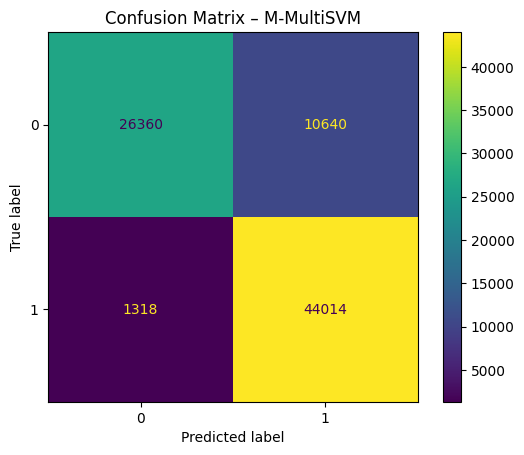

In [5]:
metrics_mmsvm = evaluate_m_multisvm(y_test, y_pred, y_score, model_name="M-MultiSVM", show_matrix=True, show_roc=True)

Lưu lại các đặc trưng và kết quả sau khi train xong

In [35]:
import joblib
import os

save_dir = CONFIG["save_dir"]
os.makedirs(save_dir, exist_ok=True)

# Lưu đặc trưng và nhãn
joblib.dump({
    "X_train_sel": X_train_sel,
    "X_test_sel": X_test_sel,
    "y_train": y_train,
    "y_test": y_test
}, os.path.join(save_dir, "final_features.pkl"))


print(f"✅ Đã lưu đặc trưng và nhãn tại {save_dir}/final_features.pkl")

# Lưu kết quả dự đoán
joblib.dump({
    "y_pred": y_pred,
    "y_score": y_score,
    "metrics_mmsvm": metrics_mmsvm,
}, os.path.join(save_dir, "m_multisvm_results.pkl"))

print("✅ Đã lưu kết quả dự đoán & đánh giá của M‑MultiSVM")

✅ Đã lưu đặc trưng và nhãn tại ../preprocessed/unsw-nb15/final_features.pkl
✅ Đã lưu kết quả dự đoán & đánh giá của M‑MultiSVM


Load lại các đặc trưng và kết quả

In [3]:
import joblib
import os

# Đường dẫn tới thư mục đã lưu
save_dir = CONFIG["save_dir"]

# Load đặc trưng và nhãn
feature_data = joblib.load(os.path.join(save_dir, "final_features.pkl"))
X_train_sel = feature_data["X_train_sel"]
X_test_sel = feature_data["X_test_sel"]
y_train = feature_data["y_train"]
y_test = feature_data["y_test"]

print("✅ Đã load đặc trưng và nhãn.")

# Load kết quả dự đoán và đánh giá
results_data = joblib.load(os.path.join(save_dir, "m_multisvm_results.pkl"))
y_pred = results_data["y_pred"]
y_score = results_data["y_score"]
metrics_mmsvm = results_data["metrics_mmsvm"]

print("✅ Đã load kết quả dự đoán và đánh giá của M‑MultiSVM.")

✅ Đã load đặc trưng và nhãn.
✅ Đã load kết quả dự đoán và đánh giá của M‑MultiSVM.
